# Phase 5: Customer Segmentation & Conversion Funnel Analysis
**Project:** Marketing Campaign A/B Test and Conversion Funnel Analysis  
**Audience:** Hiring Managers, Data & Analytics Leadership  

---
### Objective
Uncover granular behavioral patterns to answer:
1. **Ad-Exposure Funnel & Productivity**: At what exposure level does the ad campaign maximize lift, and where does it over-saturate?
2. **Impression Productivity**: How many incremental conversions are generated per 1,000 ad impressions across buckets?
3. **Budget Concentration Trap**: How many impressions are swallowed by hyper-exposed users vs causal conversion output?
4. **Temporal Dynamics**: Which days of the week and dayparts drive peak conversion lift versus flat or non-significant response?

> **Important Methodological Note:** Ad exposure levels (`total_ads`) were **not randomly assigned**. Exposure is an observational outcome of browsing duration. Comparing Treatment vs Control within each bucket helps control for engagement, but these tiers represent post-hoc behavioral segments rather than randomized treatment arms.


In [1]:
import os
import sqlite3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 11

print("Dependencies loaded successfully.")


Dependencies loaded successfully.


## 1. Ad-Exposure Funnel Progression & Impression Distribution

In [2]:
# Resolve db path
db_path = os.path.join("..", "data", "marketing_ab.db")
if not os.path.exists(db_path):
    db_path = os.path.join("data", "marketing_ab.db")

conn = sqlite3.connect(db_path)

q_funnel = '''
WITH bucketed AS (
    SELECT 
        user_id,
        test_group,
        converted,
        total_ads,
        CASE 
            WHEN total_ads BETWEEN 1 AND 5 THEN '01. 1-5 ads'
            WHEN total_ads BETWEEN 6 AND 10 THEN '02. 6-10 ads'
            WHEN total_ads BETWEEN 11 AND 20 THEN '03. 11-20 ads'
            WHEN total_ads BETWEEN 21 AND 50 THEN '04. 21-50 ads'
            WHEN total_ads BETWEEN 51 AND 100 THEN '05. 51-100 ads'
            ELSE '06. 100+ ads'
        END AS exposure_bucket
    FROM campaign_results
),
total_agg AS (
    SELECT COUNT(*) AS total_pop, SUM(total_ads) AS total_imp FROM campaign_results
)
SELECT 
    b.exposure_bucket,
    COUNT(b.user_id) AS total_users,
    ROUND(100.0 * COUNT(b.user_id) / t.total_pop, 2) AS user_share_pct,
    SUM(b.total_ads) AS total_impressions,
    ROUND(100.0 * SUM(b.total_ads) / t.total_imp, 2) AS impression_share_pct,
    ROUND(AVG(b.total_ads), 1) AS avg_ads_per_user,
    SUM(CASE WHEN b.test_group = 'ad' THEN 1 ELSE 0 END) AS ad_users,
    SUM(CASE WHEN b.test_group = 'ad' THEN b.total_ads ELSE 0 END) AS ad_impressions,
    SUM(CASE WHEN b.test_group = 'ad' AND b.converted = 1 THEN 1 ELSE 0 END) AS ad_conversions,
    ROUND(AVG(CASE WHEN b.test_group = 'ad' THEN b.converted END) * 100.0, 4) AS ad_cr_pct,
    SUM(CASE WHEN b.test_group = 'psa' THEN 1 ELSE 0 END) AS psa_users,
    SUM(CASE WHEN b.test_group = 'psa' AND b.converted = 1 THEN 1 ELSE 0 END) AS psa_conversions,
    ROUND(AVG(CASE WHEN b.test_group = 'psa' THEN b.converted END) * 100.0, 4) AS psa_cr_pct,
    ROUND(AVG(CASE WHEN b.test_group = 'ad' THEN b.converted END) * 100.0 - 
          AVG(CASE WHEN b.test_group = 'psa' THEN b.converted END) * 100.0, 4) AS absolute_lift_pct_pts
FROM bucketed b
CROSS JOIN total_agg t
GROUP BY b.exposure_bucket
ORDER BY b.exposure_bucket;
'''

df_funnel = pd.read_sql_query(q_funnel, conn)
# Calculate incremental conversions and efficiency per 1k impressions
df_funnel['expected_baseline_conv'] = df_funnel['ad_users'] * (df_funnel['psa_conversions'] / df_funnel['psa_users'])
df_funnel['incremental_conversions'] = df_funnel['ad_conversions'] - df_funnel['expected_baseline_conv']
df_funnel['inc_conv_per_1k_imp'] = (df_funnel['incremental_conversions'] / df_funnel['ad_impressions']) * 1000.0

df_funnel[['exposure_bucket', 'user_share_pct', 'impression_share_pct', 'ad_cr_pct', 'psa_cr_pct', 'absolute_lift_pct_pts', 'incremental_conversions', 'inc_conv_per_1k_imp']]


,exposure_bucket,user_share_pct,impression_share_pct,ad_cr_pct,psa_cr_pct,absolute_lift_pct_pts,incremental_conversions,inc_conv_per_1k_imp
0,01. 1-5 ads,30.24,3.17,0.2512,0.2799,-0.0286,-48.660094,-0.110134
1,02. 6-10 ads,14.11,4.34,0.4853,0.6735,-0.1882,-149.681113,-0.246118
2,03. 11-20 ads,21.68,13.35,0.8400,0.8193,0.0207,25.552771,0.013555
3,04. 21-50 ads,22.24,28.23,2.9154,2.1777,0.7377,926.155874,0.233935
4,05. 51-100 ads,7.82,21.87,11.6311,5.7744,5.8566,2585.651376,0.844303
5,06. 100+ ads,3.92,29.04,17.1352,11.8812,5.2540,1158.722772,0.285536


## 2. Visualizing Campaign Lift & Impression Productivity
- **Left Panel**: Conversion Rate by Exposure Bucket (Treatment vs Control).
- **Right Panel**: Impression Productivity (Incremental Conversions generated per 1,000 Ad Impressions). Notice the peak at 51-100 ads (0.844) followed by a sharp drop in 100+ ads (0.286).


C:\Users\saadb\AppData\Local\Temp\ipykernel_22156\868052169.py:29: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(df_funnel['exposure_bucket'], rotation=15)


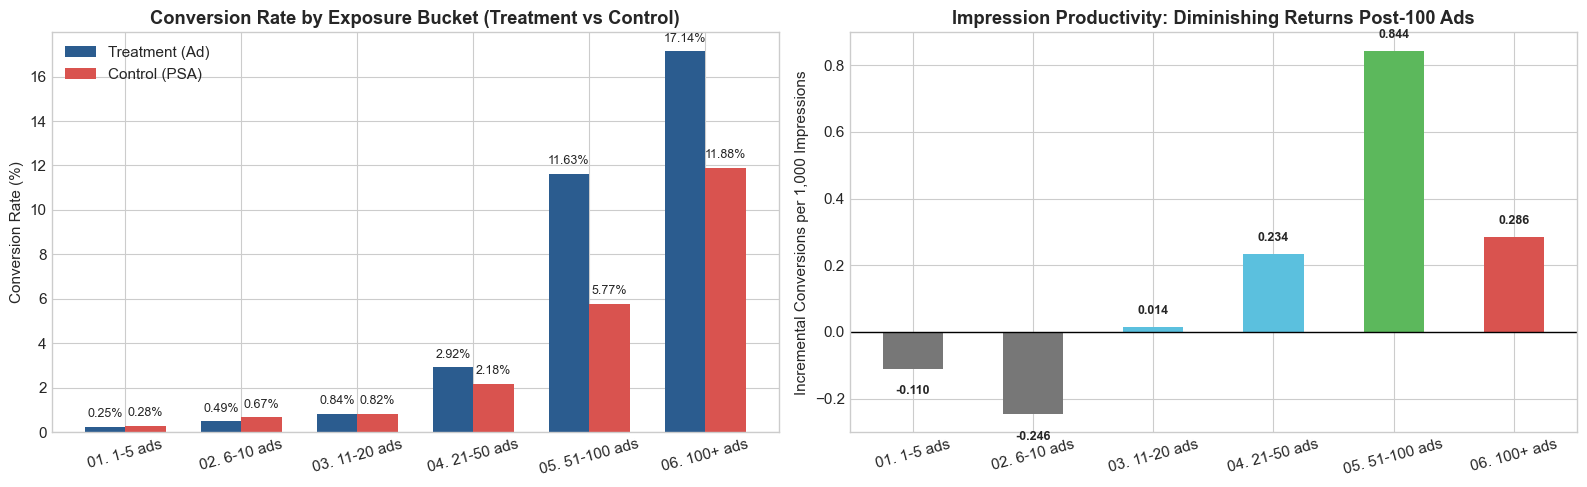

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Subplot 1: Conversion Rate by Bucket (Ad vs PSA)
x = np.arange(len(df_funnel['exposure_bucket']))
width = 0.35

rects1 = axes[0].bar(x - width/2, df_funnel['ad_cr_pct'], width, label='Treatment (Ad)', color='#2b5c8f')
rects2 = axes[0].bar(x + width/2, df_funnel['psa_cr_pct'], width, label='Control (PSA)', color='#d9534f')

axes[0].set_ylabel('Conversion Rate (%)')
axes[0].set_title('Conversion Rate by Exposure Bucket (Treatment vs Control)', fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(df_funnel['exposure_bucket'], rotation=15)
axes[0].legend()

for bar in rects1:
    y = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2.0, y + 0.3, f'{y:.2f}%', ha='center', va='bottom', fontsize=9)

for bar in rects2:
    y = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2.0, y + 0.3, f'{y:.2f}%', ha='center', va='bottom', fontsize=9)

# Subplot 2: Incremental Conversions per 1,000 Impressions
prod_bars = axes[1].bar(df_funnel['exposure_bucket'], df_funnel['inc_conv_per_1k_imp'], color=['#777777', '#777777', '#5bc0de', '#5bc0de', '#5cb85c', '#d9534f'], width=0.5)
axes[1].axhline(0, color='black', linewidth=1)
axes[1].set_ylabel('Incremental Conversions per 1,000 Impressions')
axes[1].set_title('Impression Productivity: Diminishing Returns Post-100 Ads', fontweight='bold')
axes[1].set_xticklabels(df_funnel['exposure_bucket'], rotation=15)

for bar in prod_bars:
    y = bar.get_height()
    va = 'bottom' if y >= 0 else 'top'
    axes[1].text(bar.get_x() + bar.get_width()/2.0, y + (0.03 if y >= 0 else -0.05), f'{y:.3f}', ha='center', va=va, fontweight='bold', fontsize=9)

plt.tight_layout()
plt.show()


## 3. Day of Week & Daypart Temporal Analysis

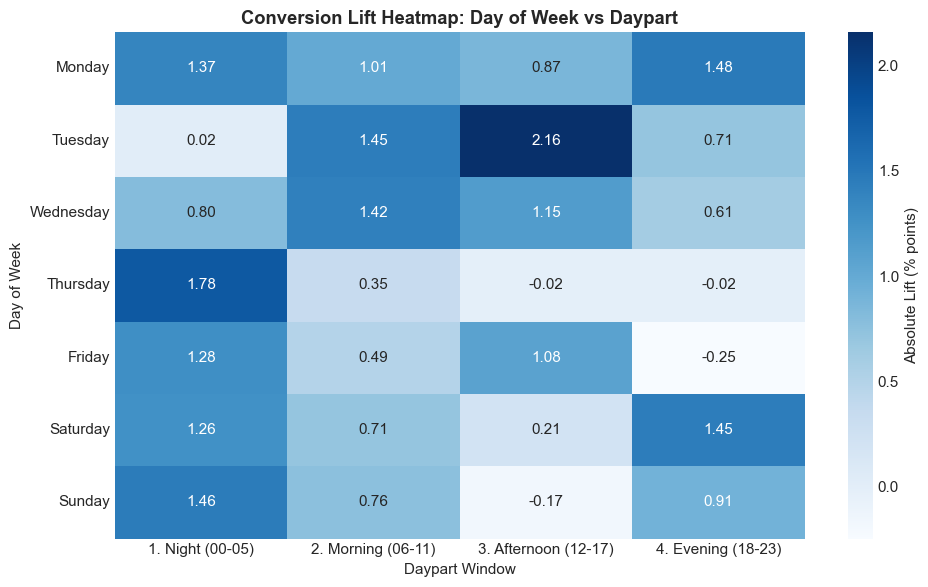

In [4]:
q_heatmap = '''
WITH base AS (
    SELECT 
        most_ads_day,
        CASE 
            WHEN most_ads_hour BETWEEN 0 AND 5 THEN '1. Night (00-05)'
            WHEN most_ads_hour BETWEEN 6 AND 11 THEN '2. Morning (06-11)'
            WHEN most_ads_hour BETWEEN 12 AND 17 THEN '3. Afternoon (12-17)'
            ELSE '4. Evening (18-23)'
        END AS daypart,
        test_group,
        converted
    FROM campaign_results
)
SELECT 
    most_ads_day,
    daypart,
    ROUND(AVG(CASE WHEN test_group = 'ad' THEN converted END) * 100.0, 2) AS ad_cr_pct,
    ROUND(AVG(CASE WHEN test_group = 'psa' THEN converted END) * 100.0, 2) AS psa_cr_pct,
    ROUND((AVG(CASE WHEN test_group = 'ad' THEN converted END) - AVG(CASE WHEN test_group = 'psa' THEN converted END)) * 100.0, 2) AS abs_lift_pct_pts
FROM base
GROUP BY most_ads_day, daypart;
'''

df_heat = pd.read_sql_query(q_heatmap, conn)
conn.close()

# Pivot for heatmap
pivot_lift = df_heat.pivot(index='most_ads_day', columns='daypart', values='abs_lift_pct_pts')
# Order days of week
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
pivot_lift = pivot_lift.reindex(day_order)

plt.figure(figsize=(10, 6))
sns.heatmap(pivot_lift, annot=True, fmt='.2f', cmap='Blues', cbar_kws={'label': 'Absolute Lift (% points)'})
plt.title('Conversion Lift Heatmap: Day of Week vs Daypart', fontweight='bold')
plt.xlabel('Daypart Window')
plt.ylabel('Day of Week')
plt.tight_layout()
plt.show()


## 4. Key Takeaways & Recommendations
1. **Impression Productivity Sweet Spot**: The 51–100 tier delivers peak efficiency (**0.844 incremental conversions per 1,000 impressions**). Beyond 100 ads, productivity plummets by 66% to **0.286**, signaling severe diminishing returns.
2. **Frequency Capping**: An empirical cap around 100 impressions—tested against a holdout group prior to full rollout—protects ad spend without cutting into high-performing frequency tiers.
3. **Low-Exposure Reality**: Visitors seeing 1–10 ads (44% of visitors) show no detectable lift, indicating that minimal exposure on low-intent bouncing traffic fails to alter conversion behavior.
4. **Daypart Strategy**: Monday and Tuesday demonstrate strong, statistically validated lift. Daytime dayparts show similar lift (+0.68 to +0.86 pts), while late-night relative lift is an artifact of tiny control conversions (1 conversion in 734 users).
